# 11 - Image Quality Metrics: MSE, PSNR, SSIM, and Edge Retention

For reference \(f\) and estimate \(g\), each with \(M\times N\) pixels,

\[
\mathrm{MSE}=\frac{1}{MN}\sum_{x=1}^{M}\sum_{y=1}^{N}[f(x,y)-g(x,y)]^2,
\qquad
\mathrm{PSNR}=10\log_{10}\left(\frac{L^2}{\mathrm{MSE}}\right),
\]

where \(L\) is the maximum intensity. SSIM compares local mean, variance, and covariance. Edge retention compares gradient energy before and after processing.

In [1]:
from pathlib import Path
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

def find_course_root() -> Path:
    """Locate the cloned course repository without a machine-specific path."""
    candidates = []
    configured = os.environ.get("VISION_ROBOTICA_REPO")
    if configured:
        candidates.append(Path(configured).expanduser())
    current = Path.cwd().resolve()
    candidates.extend([current, *current.parents])
    for candidate in candidates:
        if (candidate / "imagenes").is_dir() and (candidate / "requirements.txt").is_file():
            return candidate
    raise FileNotFoundError(
        "Course repository not found. Run the notebook from the cloned repository root "
        "or define VISION_ROBOTICA_REPO."
    )

ROOT = find_course_root()
COURSE_IMAGES = ROOT / "imagenes"
STUDENT_IMAGES = ROOT / "student_work" / "imagenes"
STUDENT_IMAGES.mkdir(parents=True, exist_ok=True)

def load_rgb(filename: str) -> np.ndarray:
    path = COURSE_IMAGES / filename
    image_bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if image_bgr is None:
        raise FileNotFoundError(f"Official course image not found: {path}")
    return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

print(f"Course root: {ROOT}")
print(f"Official images: {COURSE_IMAGES}")
print(f"Student images: {STUDENT_IMAGES}")

Course root: C:\Users\20808\Documents\Repositorios\Vision_en_Robotica
Official images: C:\Users\20808\Documents\Repositorios\Vision_en_Robotica\imagenes
Student images: C:\Users\20808\Documents\Repositorios\Vision_en_Robotica\student_work\imagenes


In [2]:
from skimage.metrics import structural_similarity

image_rgb = load_rgb("lenna.png")
reference = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)
rng = np.random.default_rng(4012)

gaussian_noisy = np.clip(reference.astype(np.float32) + rng.normal(0, 20, reference.shape), 0, 255).astype(np.uint8)
impulse_noisy = reference.copy()
mask = rng.random(reference.shape)
impulse_noisy[mask < 0.03] = 0
impulse_noisy[(mask >= 0.03) & (mask < 0.06)] = 255

candidates = {
    "Gaussian noisy": gaussian_noisy,
    "Gaussian + mean": cv2.blur(gaussian_noisy, (5, 5)),
    "Gaussian + Gaussian": cv2.GaussianBlur(gaussian_noisy, (5, 5), 1.2),
    "Impulse noisy": impulse_noisy,
    "Impulse + median": cv2.medianBlur(impulse_noisy, 5),
    "Impulse + bilateral": cv2.bilateralFilter(impulse_noisy, 9, 45, 45),
}

In [3]:
def mse(reference: np.ndarray, test: np.ndarray) -> float:
    delta = reference.astype(np.float64) - test.astype(np.float64)
    return float(np.mean(delta**2))

def psnr(reference: np.ndarray, test: np.ndarray, peak: float = 255.0) -> float:
    error = mse(reference, test)
    return float("inf") if error == 0 else float(10 * np.log10(peak**2 / error))

def edge_energy(image: np.ndarray) -> float:
    gx = cv2.Sobel(image, cv2.CV_32F, 1, 0)
    gy = cv2.Sobel(image, cv2.CV_32F, 0, 1)
    return float(np.sum(cv2.magnitude(gx, gy)))

reference_edge_energy = edge_energy(reference)
rows = []
for name, image in candidates.items():
    rows.append((
        name,
        mse(reference, image),
        psnr(reference, image),
        structural_similarity(reference, image, data_range=255),
        edge_energy(image) / reference_edge_energy,
    ))

print(f"{'Result':24s} {'MSE':>10s} {'PSNR':>10s} {'SSIM':>10s} {'Edge ratio':>12s}")
for name, error, quality, similarity, edge_ratio in rows:
    print(f"{name:24s} {error:10.2f} {quality:10.2f} {similarity:10.4f} {edge_ratio:12.3f}")

Result                          MSE       PSNR       SSIM   Edge ratio
Gaussian noisy               397.94      22.13     0.3692        2.214
Gaussian + mean               87.39      28.72     0.7758        0.773
Gaussian + Gaussian           64.44      30.04     0.7849        0.941
Impulse noisy               1121.96      17.63     0.2844        2.594
Impulse + median              50.00      31.14     0.8718        0.664
Impulse + bilateral          858.01      18.80     0.3113        1.867


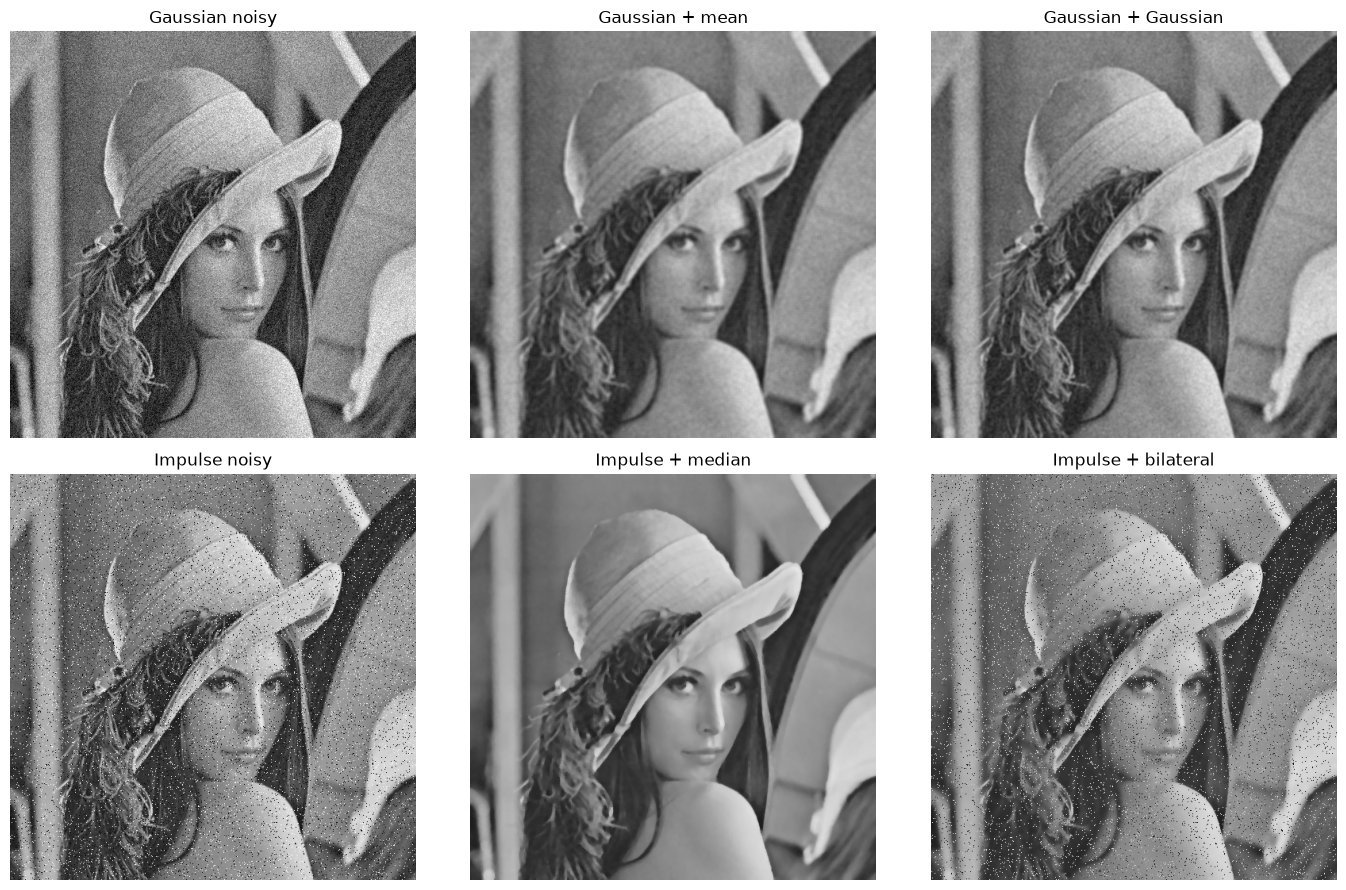

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
for axis, (name, image) in zip(axes.ravel(), candidates.items()):
    axis.imshow(image, cmap="gray", vmin=0, vmax=255)
    axis.set_title(name)
    axis.axis("off")
plt.tight_layout()
plt.show()

## Interpretation

MSE and PSNR emphasize pixelwise agreement. SSIM emphasizes local structural agreement. The edge ratio detects broad loss or amplification of gradient energy but does not identify which edges changed. A robot-facing conclusion also requires a metric for the actual task, such as feature repeatability, mask IoU, or detection accuracy.